## Imports

In [ ]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
from collections import defaultdict
import pickle
import sys
import math
from matplotlib.ticker import FuncFormatter
import os

sys.path.append(str(Path.cwd().parent))

from src import preprocessing
from src import algorithms
from src import visualizations


### Output folder setup

This cell defines the current experiment cycle and creates the results folder for that run.

- `version = "rerun"` sets the current cycle
- `path = f"../Results/Built_from_scratch_population/Cycle_{version}"` creates `Results/Built_from_scratch_population/Cycle_rerun"`
- if you want to run cycle 02, change `version = "01"` to `version = "02"` and rerun the notebook

Later in the notebook, the pickle/plot save lines are currently commented out. Once you want to store results for this cycle, uncomment those lines.

To run 10 cycles, either:
- change `version` manually for each cycle and run the notebook 10 times, or
- refactor the notebook to loop over `version` values automatically

In [ ]:
version = "rerun"

path = f"../Results/Built_from_scratch_population/Cycle_{version}"
os.makedirs(path, exist_ok=True)

## Parameters for creating the map of copenhagen

In [ ]:
# parameters of grid
resolution = 8

prompt = "Copenhagen Municipality, Denmark" 

prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

proj_crs = "EPSG:2062"

## Importing the postal-code based population values

Data extracted form Statistics Denmark and data-science.dk

In [ ]:
# Load postal-code boundaries
postal_gdf = gpd.read_file(
    "../data/Postal_code_data/"
    "86249533323639c4792ccbd48b0d9449f543d83f9e5a2f612a7ae700bb08c9ac/"
    "wgs84_geojson/postnummerinddeling.geojson"
)

# Load the populations based on postal codes
pop_df = preprocessing.clean_postal_codes(
    "../data/Postal_code_data/20264139490617746621POSTNR139926258718.csv"
)

# Make sure postal-code field is same format
postal_gdf["postnummer"] = postal_gdf["postnummer"].astype(str)
pop_df["postal_code"] = pop_df["postal_code"].astype(str)

## Grid creation with function from src/preprocessing.py

In [ ]:
grid, points, my_polygon = preprocessing.Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


### Evaluate the grid to see if it looks as expected.

Text(0.5, 1.0, 'Grid over Copenhagne DK.')

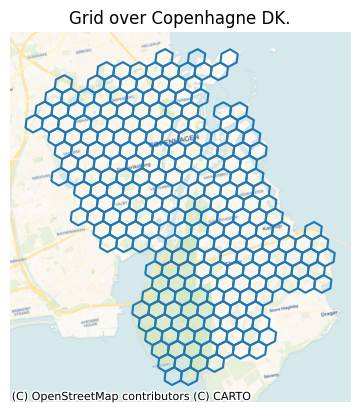

In [ ]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagen DK.")

## Merge the postal-code population number onto the grid

In [ ]:
grid_with_pop, postal_hex_intersections = algorithms.allocate_population_to_hexagons(
    grid=grid,
    postal_gdf=postal_gdf,
    population_df=pop_df,
    postal_code_col="postnummer",
    population_code_col="postal_code",
    population_col="population"
)

pointes_weighted = points.merge(
    grid_with_pop[["cell_id", "hex_population"]],
    on="cell_id",
    how="left"
)

pointes_weighted["hex_population"] = pointes_weighted["hex_population"].fillna(0)
pointes_weighted["weight"] = pointes_weighted["hex_population"]

## Visualize the population map based on the postal-code

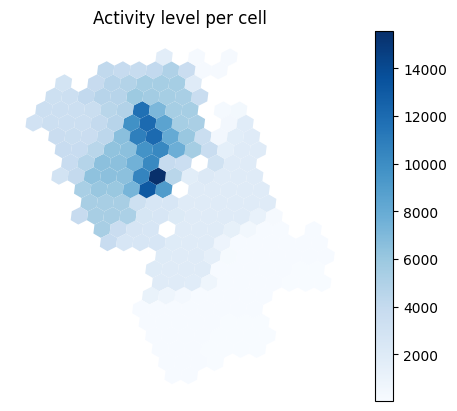

In [ ]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

## Create the OD matrix - creating the pair list and random weight assigned to this pair
#### If data isnt created or new travel data needs to be generated, use the following line to create the OD matrix and save it as a CSV. 

In [ ]:
# od_df_tocsv = preprocessing.generate_trip_weight_V2(pointes_weighted, population_col="weight", seed=154)
# od_df_tocsv.to_csv("../data/od_data_matrix.csv", index=False)

#### If you already have the CSV, you can skip this step and directly load it with pd.read_csv() as shown in the next cell.

In [ ]:
od_df = pd.read_csv("../data/od_data_matrix.csv")

## Calculate weight for each hexagon based on previuoslyu created OD matrix and extract total demand

In [ ]:
pointes_weighted_od = preprocessing.create_weights(points, od_df)

## Finding total system demand
total_demand = od_df["weight"].sum()

#### Precompute symmetric OD pair weights for faster scoring. This aggregates od_df demand into a dictionary keyed by unordered origin-destination pairs

In [ ]:
# Optimized version of calc_score 
pair_weights = defaultdict(float)
for row in od_df.itertuples():
    o, d, w = row.o, row.d, row.weight
    key = (min(o, d), max(o, d))
    pair_weights[key] += w

### Find the valid neighbors moves for GA-route builder logic

In [ ]:
valid_connections = preprocessing.finding_neighbors(pointes_weighted_od, grid)

possible_neighbors = grid.merge(
    valid_connections[["cell_id", "vicinity"]],
    on="cell_id",
    how="left"
)

## Visualize the hexagon demand based on OD data


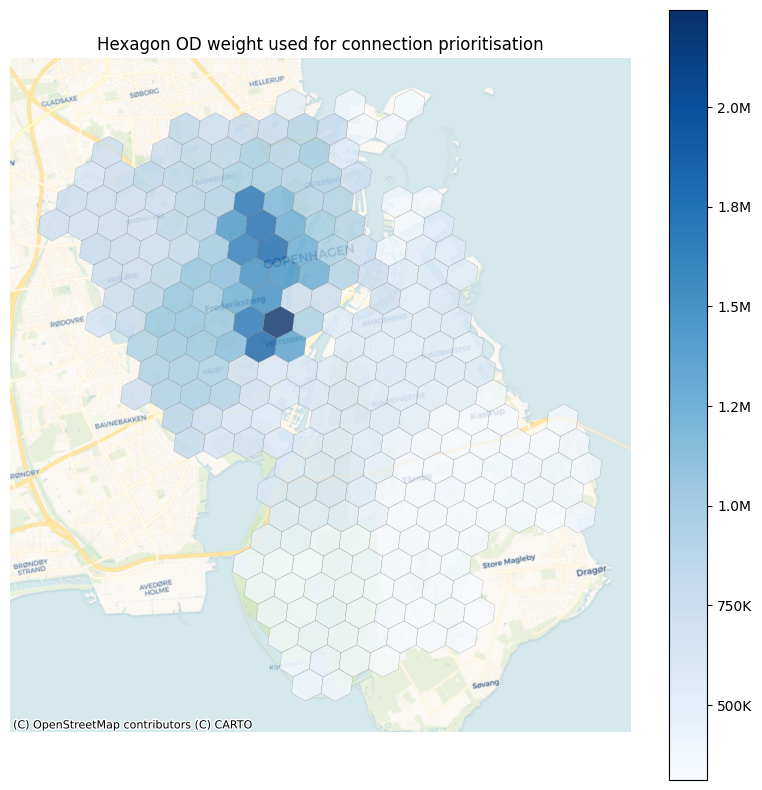

In [ ]:
# Visualise the actual OD-based hexagon weights used for prioritisation

hex_od_weights = preprocessing.create_weights(points, od_df)

grid_od_heatmap = grid.merge(
    hex_od_weights[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_od_heatmap["weight"] = (
    pd.to_numeric(grid_od_heatmap["weight"], errors="coerce")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 10))

grid_od_heatmap.plot(
    ax=ax,
    column="weight",
    cmap="Blues",
    legend=True,
    linewidth=0.2,
    edgecolor="grey",
    alpha=0.8,
    # legend_kwds={
        #"label": "OD weight",
        #"shrink": 0.7
    #}
)

cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.Voyager,
    crs=grid_od_heatmap.crs
)

# Format legend numbers nicely
legend = ax.get_figure().get_axes()[1]

legend.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
        f"{x/1_000_000:.1f}M" if x >= 1_000_000
        else f"{x/1_000:.0f}K" if x >= 1_000
        else f"{x:.0f}"
    )
)

ax.set_axis_off()
ax.set_title("Hexagon OD weight used for connection prioritisation")

plt.show()

## The Genetic algorithm section

### Set the parameters

In [ ]:
# Parameters of GA algorithms
max_routes = 4
max_stops = 17
min_stops = 6 # Becuase existing network have a line of 6 unique stations, M1 part

total_kids = 40

num_of_generations = 20


# for selecting parents later
top_performers = 3
random_performers = 3
sample_size = 3
number_of_parents = 10

### Creation of initial population, defined as list of accepted_kids

In [ ]:
accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = pointes_weighted["cell_id"].tolist()

    routes = 0

    while routes < max_routes:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)
        has_reversed = False

        while len(route_current) < max_stops:

            if random.random() < 0.05 and len(route_current) >= min_stops:  # 5% chance to break
                break

            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)
                
            if len(route_current) > 1:
                past_node = route_current[-2]
            else:
                past_node = None

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # find the possible neighbors and their weights
            neighbor_nodes, neighbor_weights = algorithms.TriangleCheck(poss_neighbors, valid_connections, route_current)

            # dead-end handling
            route_current, restart, has_reversed = algorithms.deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed)
            
            if restart:
                continue

            if not neighbor_nodes:
                break

            next_node = random.choices(neighbor_nodes, weights=neighbor_weights, k=1)[0]


            route_current.append(next_node)        
            
        if len(route_current) >= min_stops:
            all_routes[routes] = route_current
            routes += 1
        else:
            continue
        
    # Build graph ONLY from accepted routes
    G = nx.Graph()
    
    for route_id, route in all_routes.items():
        if not isinstance(route_id, int):
            continue

        for u, v in zip(route[:-1], route[1:]):
            G.add_edge(u, v, route=route_id)
            
    if G.number_of_nodes() == 0:
        continue
            
    is_one_component = nx.is_connected(G)

    ## If it is one componnet, then calculate the score and add it to the accepted kids
    if is_one_component: 
        (all_routes["Score as %"], all_routes["AVG_Shortest Path"], all_routes["Average transfers"]) = \
            algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
        all_routes["Number of edges"] = G.number_of_edges()
        all_routes["Number of nodes"] = G.number_of_nodes()
        accepted_kids.append(all_routes)
    else:
        continue

### Return any kid from the initial popualtion by defining its identifier in a square brackets.

In [ ]:
# accepted_kids[7]

### Visualise the kids, the ids can be specified 

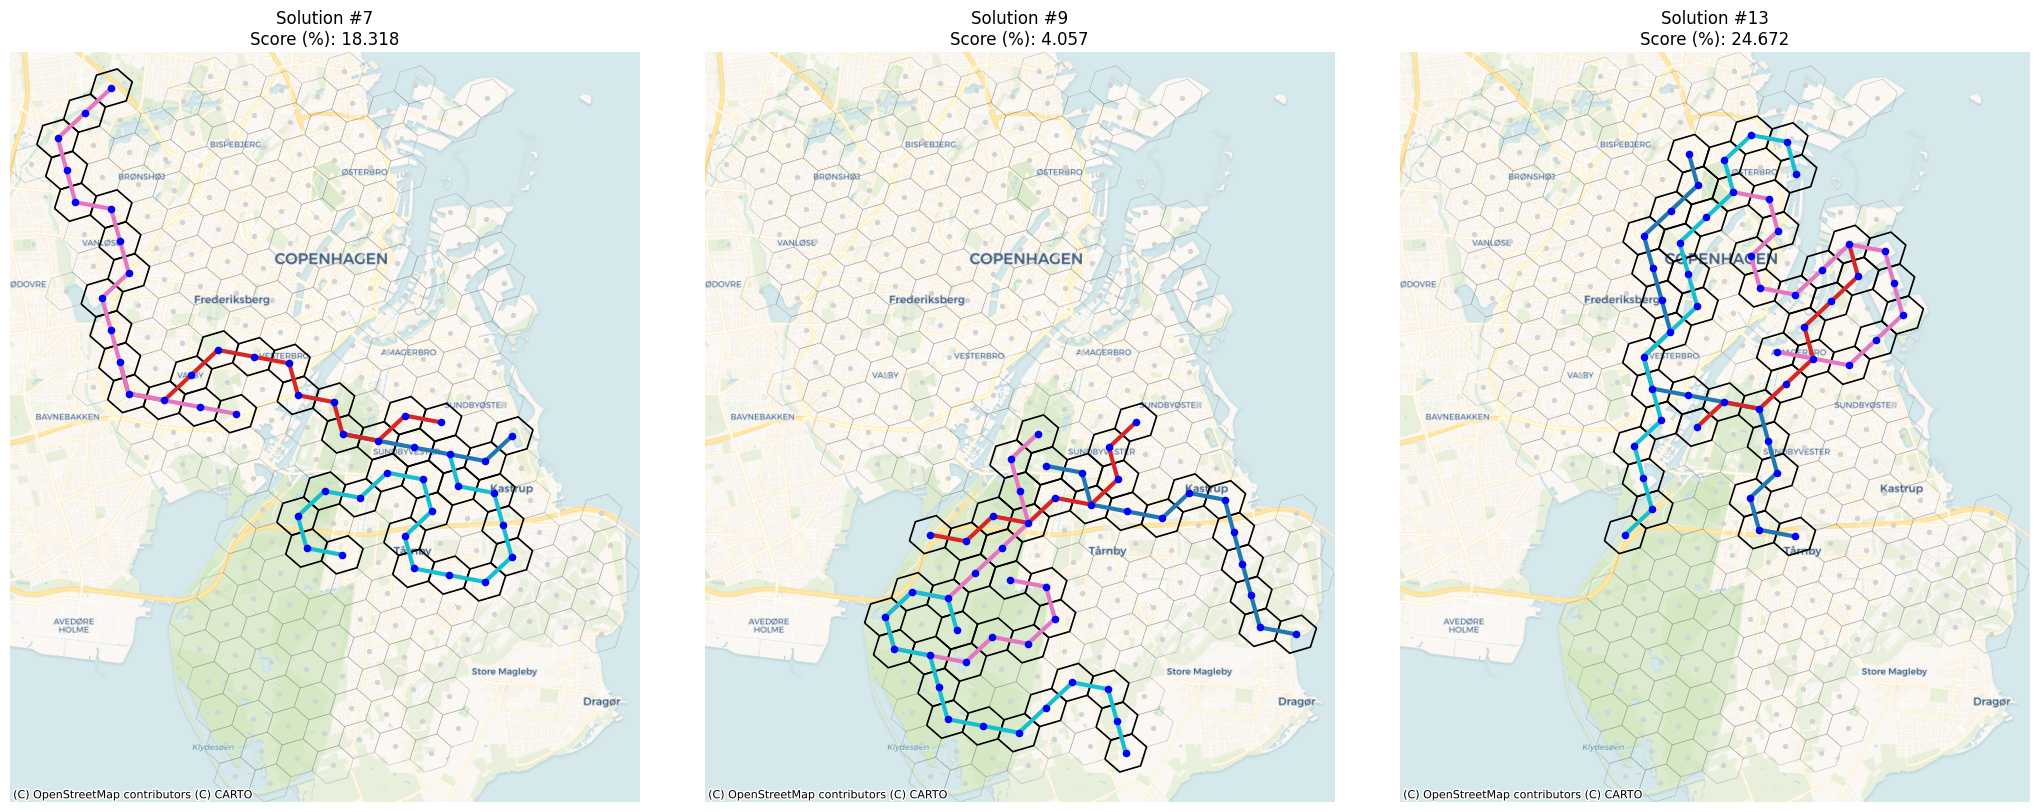

In [ ]:
# -------- REPROJECT FOR PLOTTING --------
grid_plot = grid.to_crs(epsg=3857)
points_plot = pointes_weighted.to_crs(epsg=3857)


# -------- SELECT SUBSET --------
selected_indices = [7, 9, 13]   # choose accepted_kids indices here
max_cols = 4

selected_solutions = [
    (i, accepted_kids[i])
    for i in selected_indices
    if 0 <= i < len(accepted_kids)
]

n = len(selected_solutions)

if n == 0:
    print("No valid accepted_kids indices selected.")

else:
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 8 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).ravel()

    for plot_idx, (solution_idx, solution_dict) in enumerate(selected_solutions):
        ax = axes[plot_idx]

        score = solution_dict.get("Score as %", None)
        edges_gdf = visualizations.build_edges_gdf(solution_dict, points_plot)

        used_nodes = []
        for k, v in solution_dict.items():
            if isinstance(v, (list, tuple)):
                used_nodes.extend(v)

        used_nodes = list(set(used_nodes))

        used_points = points_plot[
            points_plot["cell_id"].isin(used_nodes)
        ]

        used_hex = grid_plot[
            grid_plot["cell_id"].isin(used_nodes)
        ] if "cell_id" in grid_plot.columns else None

        ax.set_xlim(grid_plot.total_bounds[0], grid_plot.total_bounds[2])
        ax.set_ylim(grid_plot.total_bounds[1], grid_plot.total_bounds[3])

        cx.add_basemap(
            ax=ax,
            source=cx.providers.CartoDB.Voyager,
            crs=grid_plot.crs
        )

        grid_plot.boundary.plot(
            ax=ax,
            color="gray",
            linewidth=0.4,
            alpha=0.5,
            zorder=2
        )

        if used_hex is not None and not used_hex.empty:
            used_hex.boundary.plot(
                ax=ax,
                color="black",
                linewidth=1.2,
                zorder=3
            )

        if not edges_gdf.empty:
            edges_gdf.plot(
                ax=ax,
                column="route_id",
                categorical=True,
                legend=False,
                linewidth=3,
                zorder=4
            )

        points_plot.plot(
            ax=ax,
            color="lightgray",
            markersize=8,
            zorder=5
        )

        if not used_points.empty:
            used_points.plot(
                ax=ax,
                color="blue",
                markersize=20,
                zorder=6
            )

        if isinstance(score, (int, float)):
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score:.3f}")
        elif score is not None:
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score}")
        else:
            ax.set_title(f"Solution #{solution_idx}")

        ax.set_axis_off()
        ax.set_aspect("equal")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### Visualise correlation between demand score and amount of edges

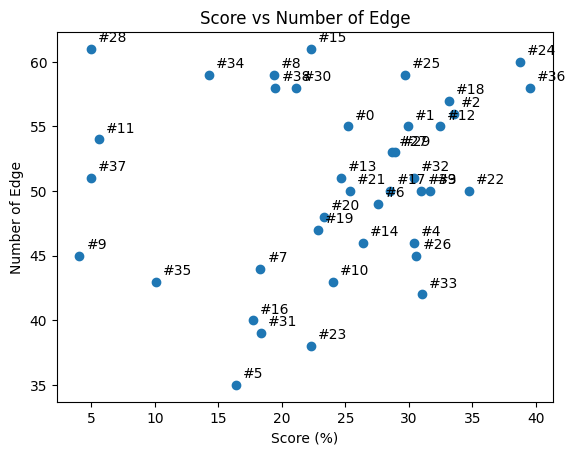

In [ ]:
x = [d["Score as %"] for d in accepted_kids]
y = [d["Number of edges"] for d in accepted_kids]

for i in range(len(x)):
    plt.annotate(f"#{i}",
                 (x[i], y[i]),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left')

plt.scatter(x, y)
plt.xlabel("Score (%)")
plt.ylabel("Number of Edge")
plt.title("Score vs Number of Edge")
plt.show()

## Running GA

### Launching the parent selection function to pre-identify 10 kids out of 40 as parents

In [ ]:
parents_of_new_gen = algorithms.select_parents(accepted_kids, top_performers, random_performers, sample_size, number_of_parents)


### This section creates multiple generations of transport networks using crossover operations 

For each generated network:
- Routes are converted into a graph structure
- Connectivity is validated using NetworkX
- evaluation metrics are calculated
- Graph statistics (edges/nodes) are stored

The final generations can be exported as a  `.pkl` dataset for later analysis

In [ ]:
generations = {}
gen_id = 1

OG_pop = {index: value for index, value in enumerate(accepted_kids)}
OG_pop = algorithms.normalize_generation(OG_pop)
generations[0] = OG_pop

while len(generations) < num_of_generations:
    kids = {}
    kid_id = 0
    while len(kids) < total_kids:
        new_kid = algorithms.bfs_crossover(parents_of_new_gen, possible_neighbors, 0.1, valid_connections)

        G = nx.Graph() 
        for route_id, route in new_kid.items():
            if not isinstance(route_id, int):
                continue

            for u, v in zip(route[:-1], route[1:]):
                G.add_edge(u, v, route=route_id)

        is_one_component = nx.is_connected(G)
        
        if is_one_component: # false then skip
            kids[kid_id] = new_kid
            (kids[kid_id]["Score as %"], kids[kid_id]["AVG_Shortest Path"], kids[kid_id]["Average transfers"]) \
            = algorithms.cal_scoreV2(G, od_df, valid_connections, pair_weights)
            kids[kid_id]["Number of edges"] = G.number_of_edges()
            kids[kid_id]["Number of nodes"] = G.number_of_nodes()
            kid_id += 1

    kids = algorithms.normalize_generation(kids)
    generations[gen_id] = kids
    gen_id += 1
    
# UNCOMMENT THIS PART TO SAVE THE GENERATIONS DATA AS PICKLE FILE

#with open(f"..//Results/Built_from_scratch_population/Cycle_{version}/{version}_gen_data.pkl", "wb") as f:
#     pickle.dump(generations, f)


{0: [37, 128, 372, 414, 107, 41, 426, 347, 335, 100, 20], 1: [187, 36, 338, 171, 30, 233, 153, 438, 127, 44, 177, 32, 449, 137, 117, 50, 122], 2: [411, 120, 189, 171, 235, 295, 306, 4, 231, 316, 435, 180, 114, 163], 3: [70, 100, 401, 251, 214, 76, 84, 348, 6, 152, 1, 168, 120, 260, 431, 367, 127], 'Score as %': np.float64(29.92250934944403), 'AVG_Shortest Path': 11.72996632996633, 'Average transfers': 1.0154882154882154, 'Number of edges': 55, 'Number of nodes': 55, 'Edges_normalized': 0.7692307692307693, 'Nodes_normalized': 0.8461538461538461, 'Shortest_normalized': 0.5880498219895736, 'Transfer_normalized': 0.05716608698110205, 'Final score': np.float64(0.12833859744537382)}


#### Generation Validation

In [ ]:
print(len(generations))
print(len(generations[0]))
print(len(generations[19][2])) # 14 values - 4 lines and 10 metadata

20
40
14


## Performance visualisation with Demand coverage % vs Edge amount

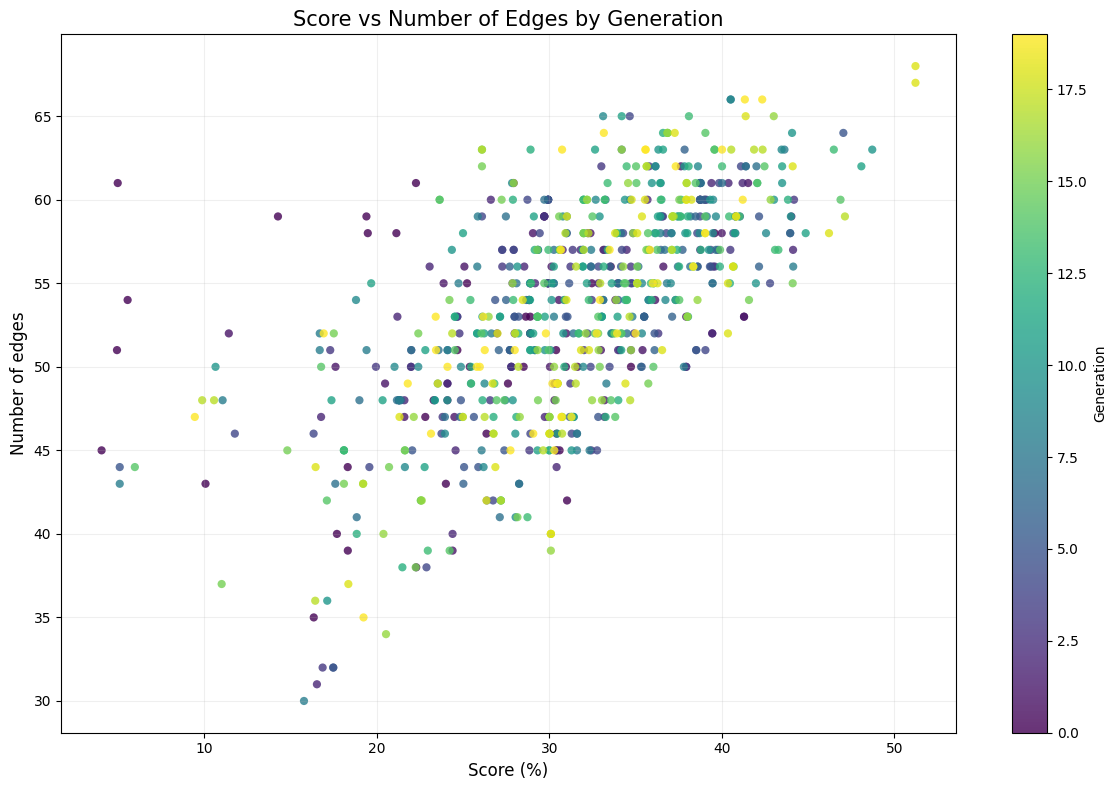

In [ ]:
# Collect all data first
x = []
y = []
gen_vals = []

for gen_name, kids_dict in generations.items():
    for kid_info in kids_dict.values():
        x.append(kid_info["Score as %"])
        y.append(kid_info["Number of edges"])
        gen_vals.append(int(gen_name))   # assumes generation names are numeric strings

# Create larger figure
plt.figure(figsize=(12, 8))

# Scatter plot with continuous colormap
scatter = plt.scatter(
    x,
    y,
    c=gen_vals,          # color by generation
    cmap="viridis",      # continuous colormap
    s=35,                # smaller points
    alpha=0.8,
    edgecolors="none"
)

# Labels and title
plt.xlabel("Score (%)", fontsize=12)
plt.ylabel("Number of edges", fontsize=12)
plt.title("Score vs Number of Edges by Generation", fontsize=15)

# Add colorbar instead of legend
cbar = plt.colorbar(scatter)
cbar.set_label("Generation")

# Optional styling
plt.grid(True, alpha=0.2)
plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

#plt.savefig(f"../Results/Built_from_scratch_population/Cycle_{version}/{version}_generation_plot_1.png", dpi=300, bbox_inches="tight")

plt.show()

## Performance visualisation with Demand coverage % acroos generations

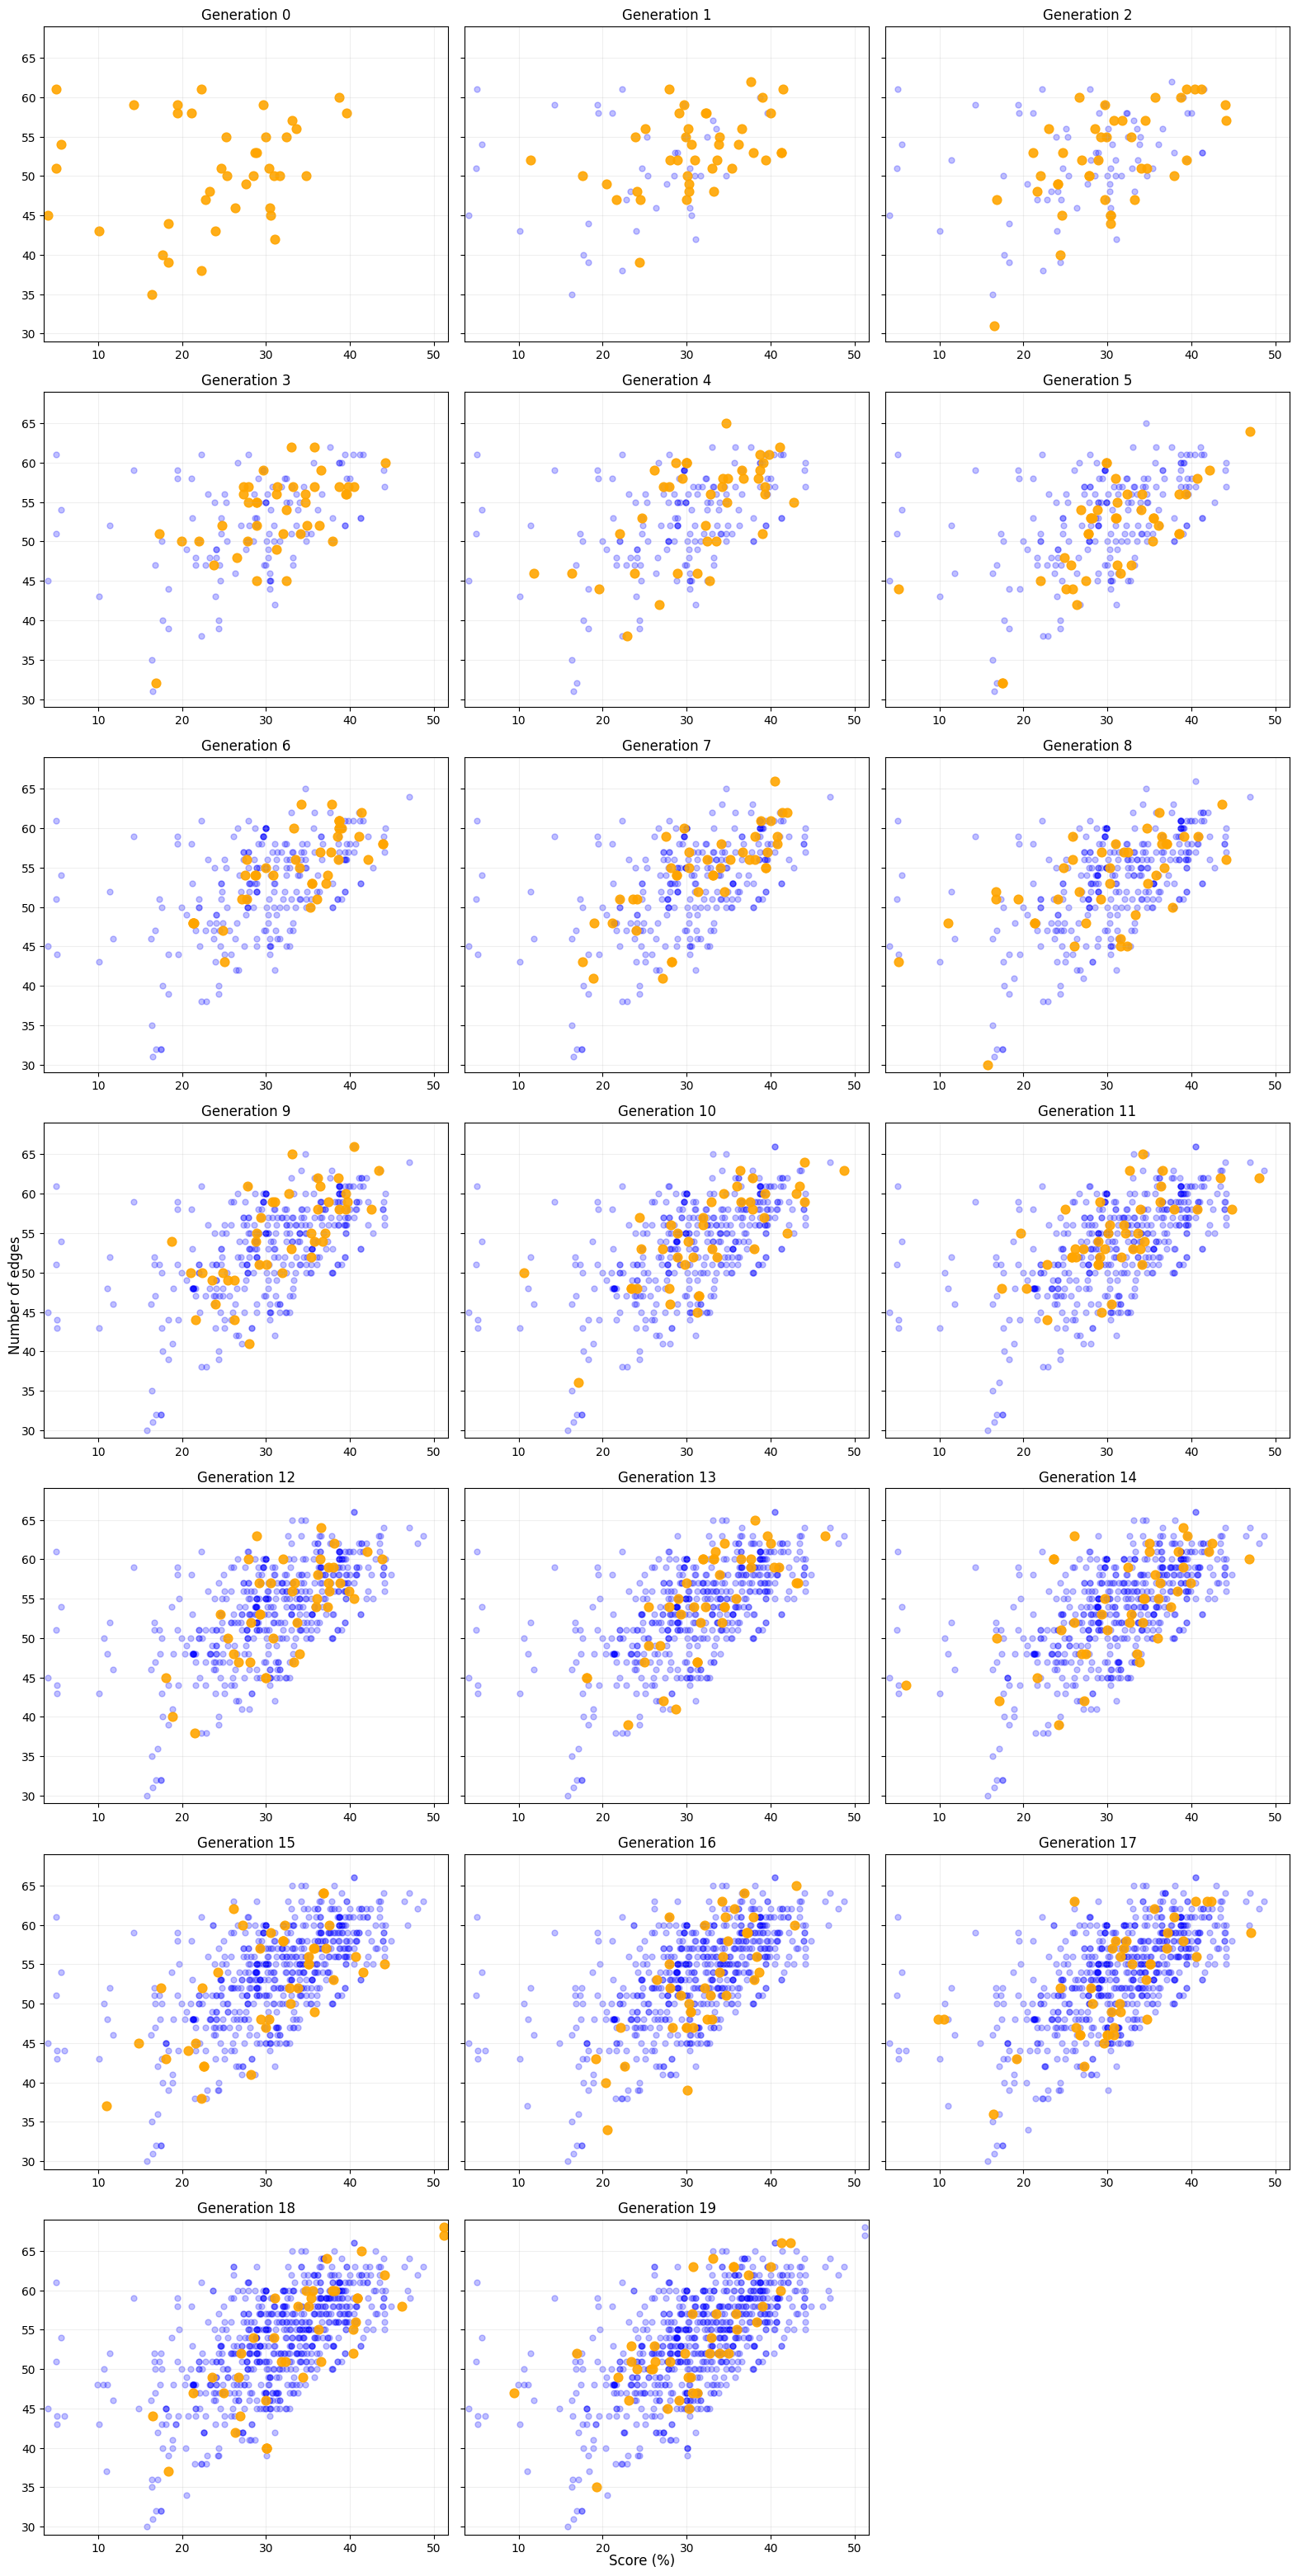

In [ ]:
# Flatten data by generation
gen_data = {}

for gen_name, kids_dict in generations.items():
    gen = int(gen_name)
    gen_data[gen] = {
        "x": [kid_info["Score as %"] for kid_info in kids_dict.values()],
        "y": [kid_info["Number of edges"] for kid_info in kids_dict.values()],
    }

gens = sorted(gen_data.keys())

# Shared axis limits for easier comparison
all_x = [v for gen in gens for v in gen_data[gen]["x"]]
all_y = [v for gen in gens for v in gen_data[gen]["y"]]

x_pad = 0.5
y_pad = 1

ncols = 3
nrows = math.ceil(len(gens) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, gen in zip(axes, gens):
    # Previous generations
    prev_x = [v for g in gens if g < gen for v in gen_data[g]["x"]]
    prev_y = [v for g in gens if g < gen for v in gen_data[g]["y"]]

    if prev_x:
        ax.scatter(
            prev_x,
            prev_y,
            s=25,
            alpha=0.25,
            label="Previous generations",
            color="blue"
        )

    # Current generation highlighted
    ax.scatter(
        gen_data[gen]["x"],
        gen_data[gen]["y"],
        s=60,
        alpha=0.9,
        label=f"Generation {gen}",
        color="orange"
    )

    ax.set_title(f"Generation {gen}")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
    ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)

# Remove empty subplot slots
for ax in axes[len(gens):]:
    ax.remove()

fig.supxlabel("Score (%)")
fig.supylabel("Number of edges")
# fig.suptitle("Score vs Number of Edges: Each Generation Highlighted", fontsize=16)

#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="upper right")
plt.tight_layout()

# UNCOMMENT THIS PART TO SAVE THIS PLOT

# plt.savefig(f"../Results/Built_from_scratch_population/Cycle_{version}/{version}_generation_plot_2.png", dpi=300, bbox_inches="tight")

plt.show()

## Extract average demand score (%) per generation

In [ ]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Score as %"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")

Generation 0 average: 24.03722983687233
Generation 1 average: 30.93300054162497
Generation 2 average: 30.304886223796693
Generation 3 average: 31.368955839709507
Generation 4 average: 31.592678203939755
Generation 5 average: 30.50282563021658
Generation 6 average: 33.735819818529876
Generation 7 average: 31.964880267218625
Generation 8 average: 29.551141105307302
Generation 9 average: 31.945186394567845
Generation 10 average: 32.57386145910159
Generation 11 average: 31.10256222649511
Generation 12 average: 32.380453285946004
Generation 13 average: 32.656284529773316
Generation 14 average: 31.64766158444952
Generation 15 average: 30.040576734318062
Generation 16 average: 31.91954315387286
Generation 17 average: 31.09195975138885
Generation 18 average: 33.9201337161865
Generation 19 average: 30.46221163396185


## Extract average of MO score

In [ ]:
# Calcuulate the average score for each genration
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Final score"].sum()
    # print(f"Generation {i}: {generation_total}")
    print(f"Generation {i} average: {generation_total / len(generations[i])}")

Generation 0 average: 0.12399009066185607
Generation 1 average: 0.1540084217294662
Generation 2 average: 0.13359216487263437
Generation 3 average: 0.13660737203470996
Generation 4 average: 0.15591629378108363
Generation 5 average: 0.15340907867404785
Generation 6 average: 0.16503601658176775
Generation 7 average: 0.17300645672546455
Generation 8 average: 0.1281484162707293
Generation 9 average: 0.15290664982157498
Generation 10 average: 0.14688166597934688
Generation 11 average: 0.15872249193367668
Generation 12 average: 0.1567130267857617
Generation 13 average: 0.14677768145021206
Generation 14 average: 0.15766561081266786
Generation 15 average: 0.13208223623967671
Generation 16 average: 0.1493953538595833
Generation 17 average: 0.15014103325510325
Generation 18 average: 0.17130297423099644
Generation 19 average: 0.14099722178252536


# Extract the best performer of each generation together witH its ID - Demand coverage %

In [ ]:
# Extract the best performer of generation and its id
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Score as %"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Score as %']}, ID: {best_performer_id}")

Generation 0: 39.57689295091527, ID: 36
Generation 1: 41.52111295867036, ID: 4
Generation 2: 44.124036759245875, ID: 26
Generation 3: 44.18083485665987, ID: 33
Generation 4: 42.79069197064399, ID: 21
Generation 5: 47.03925921282602, ID: 17
Generation 6: 43.957798839126475, ID: 8
Generation 7: 42.00297826480334, ID: 13
Generation 8: 44.13252642195458, ID: 28
Generation 9: 43.45952979846769, ID: 20
Generation 10: 48.7133162443831, ID: 3
Generation 11: 48.0817573180111, ID: 13
Generation 12: 43.829771671818044, ID: 37
Generation 13: 46.485951565226124, ID: 36
Generation 14: 46.87490923083111, ID: 10
Generation 15: 44.10358086484313, ID: 1
Generation 16: 43.00556429167888, ID: 6
Generation 17: 47.1299747608847, ID: 1
Generation 18: 51.218368993289474, ID: 12
Generation 19: 42.337817057123495, ID: 20


# Extract the best performer of each generation together wit its ID - MO score 

In [ ]:
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Final score"], reverse=True)[0]
    best_performer_id = [k for k, v in generations[i].items() if v == best_performer][0]
    print(f"Generation {i}: {best_performer['Final score']}, ID: {best_performer_id}")

Generation 0: 0.209042119648486, ID: 22
Generation 1: 0.2259605456798512, ID: 12
Generation 2: 0.19911751003917255, ID: 4
Generation 3: 0.19689618050528548, ID: 20
Generation 4: 0.22360284677774225, ID: 21
Generation 5: 0.21293698374295375, ID: 34
Generation 6: 0.23388242980117938, ID: 7
Generation 7: 0.23335942036222265, ID: 0
Generation 8: 0.20254081878777838, ID: 38
Generation 9: 0.22809095712097613, ID: 27
Generation 10: 0.22820237005234503, ID: 18
Generation 11: 0.26550203126592137, ID: 22
Generation 12: 0.21761095026240204, ID: 12
Generation 13: 0.2302878666553129, ID: 9
Generation 14: 0.23804285762913466, ID: 26
Generation 15: 0.21115353248293114, ID: 36
Generation 16: 0.22014424715036854, ID: 10
Generation 17: 0.24898994278332484, ID: 8
Generation 18: 0.2539084659763286, ID: 2
Generation 19: 0.21803382696310813, ID: 1


## Extracting the average length of the metro network, interpreted as edges
### For operator's cost approximation

### Average amount of edges

In [ ]:
# Calculate the average length of metro network for each generation

for i in range(len(generations)):
    generation_length = 0
    for j in range(len(generations[i])):
        generation_length += generations[i][j]["Number of edges"]
    # print(f"Generation {i}: {generation_length}")
    print(f"Generation {i} average: {generation_length / len(generations[i])}")

best_sol_amount_of_edges = generations[19][23]["Number of edges"]
best_solution_final_score = generations[19][25]["Number of edges"]

print(f"The best solution based on score has {best_sol_amount_of_edges} edges")
print("""This is way higher than the average amount of the edges in the generations, 
    so to solve TNDP we need to find compromise between score and the amount of edges.""")

print(f"The best solution based on our score has {best_solution_final_score} edges")

Generation 0 average: 50.6
Generation 1 average: 53.125
Generation 2 average: 52.175
Generation 3 average: 53.475
Generation 4 average: 54.3
Generation 5 average: 51.0
Generation 6 average: 55.175
Generation 7 average: 54.05
Generation 8 average: 52.85
Generation 9 average: 54.875
Generation 10 average: 54.425
Generation 11 average: 54.6
Generation 12 average: 53.75
Generation 13 average: 54.6
Generation 14 average: 54.1
Generation 15 average: 52.4
Generation 16 average: 52.675
Generation 17 average: 52.6
Generation 18 average: 53.525
Generation 19 average: 53.45
The best solution based on score has 55 edges
This is way higher than the average amount of the edges in the generations, 
    so to solve TNDP we need to find compromise between score and the amount of edges.
The best solution based on our score has 58 edges


### Average amount of nodes

In [ ]:
# Extracting the average amount of nodes as well 

for i in range(len(generations)):
    generation_nodes = 0
    for j in range(len(generations[i])):
        generation_nodes += generations[i][j]["Number of nodes"]
    # print(f"Generation {i}: {generation_nodes}")
    print(f"Generation {i} average: {generation_nodes / len(generations[i])}")

best_sol_amount_of_edges = generations[19][23]["Number of edges"]
best_solution_final_score = generations[19][25]["Number of edges"]


print(f"The best solution based on score has {best_sol_amount_of_edges} nodes")
print(""" To compare it to the existing network, amount of nodes is higher in our proposed solution, 
      so to make it fare i think we need to find the best solution with the same nodes, edges parameters""")


print(f"The best solution based on our score has {best_solution_final_score} nodes")

Generation 0 average: 49.525
Generation 1 average: 51.4
Generation 2 average: 50.675
Generation 3 average: 52.0
Generation 4 average: 52.175
Generation 5 average: 49.925
Generation 6 average: 53.7
Generation 7 average: 52.725
Generation 8 average: 50.75
Generation 9 average: 53.15
Generation 10 average: 52.375
Generation 11 average: 52.575
Generation 12 average: 52.275
Generation 13 average: 52.95
Generation 14 average: 52.775
Generation 15 average: 50.525
Generation 16 average: 50.95
Generation 17 average: 50.775
Generation 18 average: 52.1
Generation 19 average: 51.925
The best solution based on score has 55 nodes
 To compare it to the existing network, amount of nodes is higher in our proposed solution, 
      so to make it fare i think we need to find the best solution with the same nodes, edges parameters
The best solution based on our score has 58 nodes


## Results for the average shortest path

In [ ]:
for i in range(len(generations)):

    generation_short = 0

    for j in range(len(generations[i])):

        generation_short += generations[i][j]["AVG_Shortest Path"]

    avg_shortest = generation_short / len(generations[i])

    print(f"Generation {i} average: {avg_shortest}")
    
    
best_sol_shortest_path = generations[19][23]["AVG_Shortest Path"]
best_solution_shortest_path = generations[19][25]["AVG_Shortest Path"]

print(f"The best solution based on demand score % has an average shortest path of: {best_sol_shortest_path}")
print(f"The best solution based on our score has an average shortest path of: {best_solution_shortest_path}")

Generation 0 average: 9.705038943886839
Generation 1 average: 10.258613234683697
Generation 2 average: 9.909961893788127
Generation 3 average: 10.307906306855545
Generation 4 average: 9.92585093581849
Generation 5 average: 9.845339802185118
Generation 6 average: 9.653538842062979
Generation 7 average: 10.226456487356344
Generation 8 average: 9.359599686936507
Generation 9 average: 9.883013905575554
Generation 10 average: 9.903923308526057
Generation 11 average: 9.721320520005403
Generation 12 average: 9.994705163959464
Generation 13 average: 9.788367975883093
Generation 14 average: 10.05331227846392
Generation 15 average: 9.235624829625564
Generation 16 average: 9.32998295570806
Generation 17 average: 9.434406177712805
Generation 18 average: 9.83547999619208
Generation 19 average: 9.666196167159889
The best solution based on demand score % has an average shortest path of: 12.374025974025974
The best solution based on our score has an average shortest path of: 10.612781954887218


## Results for the average amount of transfers

In [ ]:
# Extracting the average amount of transfers as well

for i in range(len(generations)):

    total_transfers = 0
    count = 0

    for j in range(len(generations[i])):

        total_transfers += generations[i][j]["Average transfers"]
        count += 1

    avg_generation_transfers = total_transfers / count

    print(f"Generation {i}: {avg_generation_transfers}")
    

best_sol_shortest_path = generations[19][23]["Average transfers"]    
best_solution_shortest_path = generations[19][25]["Average transfers"]

print(f"The best solution based on score has an average amount of transfer equal to {best_sol_shortest_path}")
print(f"The best solution based on our score has an average amount of transfer equal to {best_solution_shortest_path}")

Generation 0: 1.421695378427246
Generation 1: 1.408593195538148
Generation 2: 1.4987216851936442
Generation 3: 1.3556030247819484
Generation 4: 1.430450668090899
Generation 5: 1.3202117027978182
Generation 6: 1.4091793777651707
Generation 7: 1.3102237966740202
Generation 8: 1.3118554448671533
Generation 9: 1.4015253187859964
Generation 10: 1.315021364025378
Generation 11: 1.412043315398858
Generation 12: 1.2946463183520986
Generation 13: 1.3282957801441746
Generation 14: 1.262104740511445
Generation 15: 1.3178081148404925
Generation 16: 1.3557973598323847
Generation 17: 1.3833379254497196
Generation 18: 1.2555885170683228
Generation 19: 1.2741004038898753
The best solution based on score has an average amount of transfer equal to 1.1142857142857143
The best solution based on our score has an average amount of transfer equal to 1.0983709273182958
